In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import tifffile
import seaborn as sns
import numpy as np
import re


In [4]:
# -----------------------------
# Paths
# -----------------------------

BASE_DIR = Path.cwd().parents[1]

METADATA_FILE = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "FIB_SEM_Opt_datasets.csv"
)

COMPARISON_DIR = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "comparison_figures"
    / "segmentation_quality"
)

COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -----------------------------
# Load metadata once
# -----------------------------

metadata = pd.read_csv(
    METADATA_FILE
)

quality_results = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results.csv"
)
quality_results_normalised = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results_normalised.csv"
)


# -----------------------------
# Extract image ID
# -----------------------------

def get_image_id(path):

    match = re.search(
        r"_LFP_(\d+)(?:_mask)?$",
        path.stem
    )

    if match:
        return int(match.group(1))

    return None

In [5]:
def plot_image_quality_for_param(param):

    # Load image quality results
    QUALITY_FILE = (
        BASE_DIR
        / "FIB_SEM_optimization"
        / "results"
        / "image_quality_results.csv"
    )

    quality_results = pd.read_csv(QUALITY_FILE)

    # Load segmentation results for selected parameter set
    SEG_FILE = (
        BASE_DIR
        / "FIB_SEM_optimization"
        / "results"
        / param
        / f"segmentation_quality_{param.lower()}.csv"
    )

    seg_results = pd.read_csv(SEG_FILE)

    # Keep only images that have segmentation results
    quality_results = quality_results.merge(
        seg_results[
            [
                "detector",
                "sample_state",
                "material",
                "image_id"
            ]
        ],
        on=[
            "detector",
            "sample_state",
            "material",
            "image_id"
        ],
        how="inner"
    )

    metrics = [
        "Entropy",
        "Sharpness",
        "Gradient",
        "RMS_Contrast",
        "SNR"
    ]

    # Create grid
    cols = 3
    rows = math.ceil(len(metrics) / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 8)
    )

    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        ax.bar(
            quality_results["image_id"].astype(str),
            quality_results[metric]
        )

        ax.set_title(metric)
        ax.set_xlabel("Image ID")

        ax.tick_params(
            axis="x",
            rotation=90,
            labelsize=8
        )

        ax.grid(True)

    # Remove unused axes
    for ax in axes[len(metrics):]:
        ax.axis("off")

    fig.suptitle(
        f"Image Quality Metrics (Images Used for {param})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

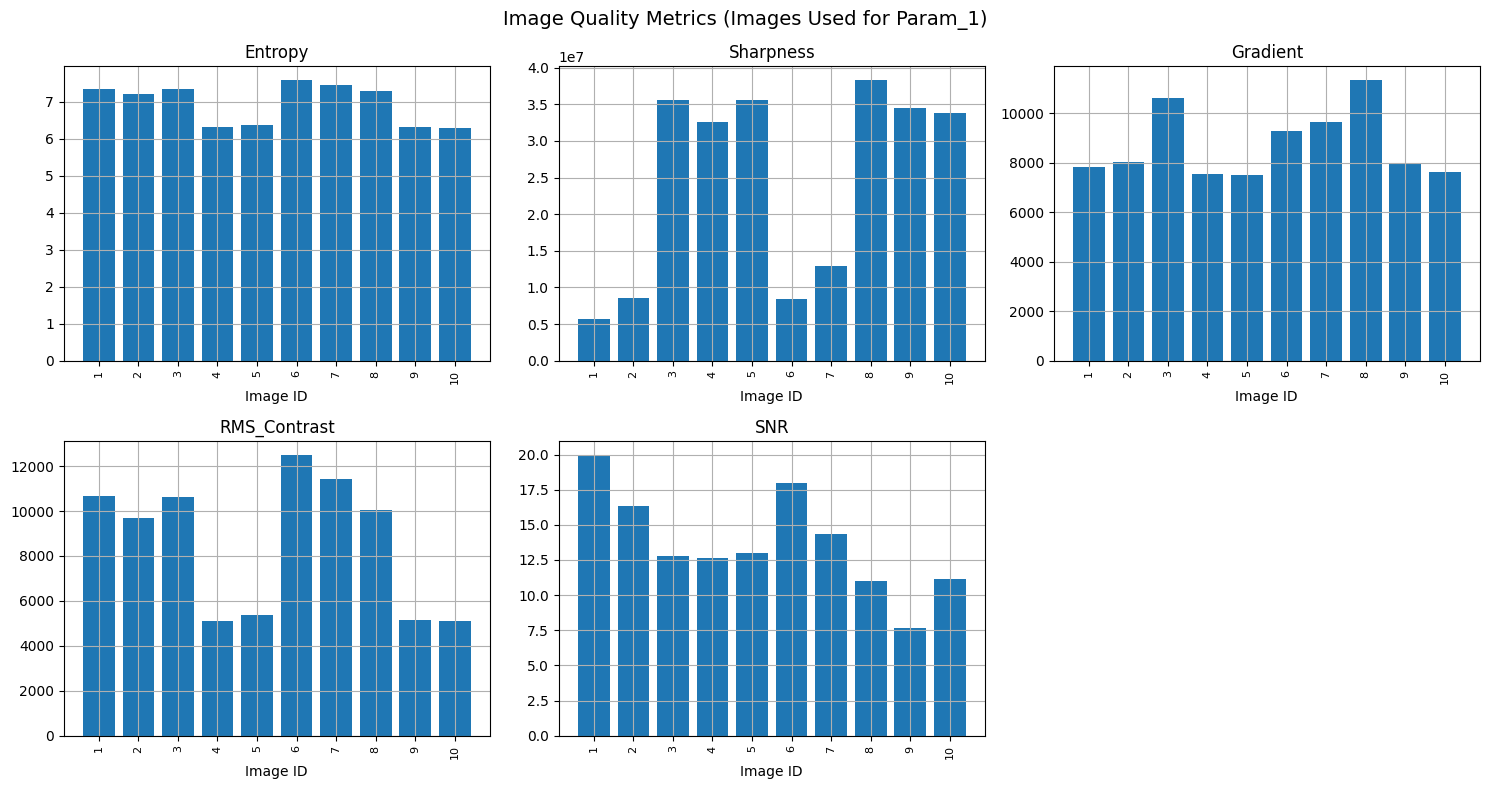

In [6]:
plot_image_quality_for_param("Param_1")

In [7]:
def plot_segmented_images(
    param,
    metadata_filter,
    title="Segmented FIB-SEM Images",
    filename="segmented_comparison",
    cols=4,
    suction_voltage=None,
    signal_out=None,
    Mode=None,
):

    """
    Plot and save segmented FIB-SEM images based on metadata filters.

    Example:

    plot_segmented_images(
        param="Param_2",
        metadata_filter=(
            (metadata["parameter_set"] == 2) &
            (metadata["current_nA"] == 0.1)
        ),
        title="Parameter Set 2 | Current 0.1 nA",
        filename="ParameterSet_2_Current_0.1nA_Segmented"
    )
    """

    # --------------------------------
    # Segmented image directory
    # --------------------------------

    BASE_DIR = Path.cwd().parents[1]

    MASK_DIR = (
        BASE_DIR
        / "FIB_SEM_optimization"
        / "images"
        / "segmented_masks"
        / param
    )


    # --------------------------------
    # Select metadata
    # --------------------------------

    selected = metadata[
        metadata_filter
    ].sort_values(
        "image_id"
    )


    if len(selected) == 0:
        print("No images found")
        return


    wanted_ids = set(
        selected["image_id"]
    )


    # --------------------------------
    # Find matching segmented images
    # --------------------------------

    image_paths = []

    for image_file in MASK_DIR.glob("*_mask.tif"):

        image_id = get_image_id(
            image_file
        )

        if image_id in wanted_ids:
            image_paths.append(
                image_file
            )


    image_paths = sorted(
        image_paths,
        key=get_image_id
    )


    n_images = len(image_paths)


    if n_images == 0:
        print("No segmented TIFF files found")
        return


    # --------------------------------
    # Figure layout
    # --------------------------------

    rows = math.ceil(
        n_images / cols
    )

    plt.close("all")

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(30, 8 * rows),
        dpi=200
    )


    if n_images == 1:
        axes = [axes]

    else:
        axes = axes.flatten()


    # --------------------------------
    # Plot segmented images
    # --------------------------------

    for ax, image_path in zip(
        axes,
        image_paths
    ):

        image = tifffile.imread(
            image_path
        )


        ax.imshow(
            image,
            cmap="gray",
            interpolation="nearest",
            aspect="equal"
        )


        image_id = get_image_id(
            image_path
        )


        meta_row = selected[
            selected["image_id"] == image_id
        ].iloc[0]


        ax.set_title(
            image_path.stem,
            fontsize=16
        )


        info = (
            f"ID: {image_id}\n"
            + (
                f"Suction Tube Voltage: {meta_row.get('suction_V', 'N/A')}\n"
                if suction_voltage is not None
                else ""
            )
            + (
                f"Mode: {meta_row.get('mode', 'N/A')}\n"
                if Mode is not None
                else ""
            )
            + f"Detector: {meta_row.get('detector', 'N/A')}\n"
            + (
                f"Signal Out: {meta_row.get('signal_out', 'N/A')}\n"
                if signal_out is not None
                else ""
            )
            + f"Current: {meta_row.get('current_nA', 'N/A')} nA\n"
            + f"Voltage: {meta_row.get('voltage_kV', 'N/A')} kV\n"
            + f"Magnification: {meta_row.get('magnification', 'N/A')}\n"
            + (
                f"Notes: {meta_row['notes']}"
                if pd.notna(meta_row["notes"])
                and str(meta_row["notes"]).strip().upper() != "NA"
                else ""
            )
        )


        ax.text(
            0.5,
            -0.15,
            info,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=12
        )


        ax.axis("off")


    # --------------------------------
    # Remove empty axes
    # --------------------------------

    for ax in axes[n_images:]:
        ax.axis("off")


    # --------------------------------
    # Figure title
    # --------------------------------

    plt.suptitle(
        title,
        fontsize=16
    )


    plt.tight_layout()


    # --------------------------------
    # Save figure
    # --------------------------------

    save_path = (
        COMPARISON_DIR
        / f"{filename}.png"
    )


    try:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    finally:

        plt.close(fig)


    print(
        f"Displayed {n_images} segmented images"
    )

    print(
        f"Saved: {save_path}"
    )

In [8]:
# ==========================================================
# Segmented mask comparison plotting function
# ==========================================================

def plot_segmented_masks_comparison(
    param,
    metadata_filter,
    row_variable,
    column_variable,
    row_order=None,
    column_order=None,
    column_map=None,
    title="Segmented Mask Comparison",
    filename="segmented_mask_comparison"
):

    # ------------------------------------------------------
    # Mask directory
    # ------------------------------------------------------

    MASK_DIR = (
        BASE_DIR
        / "FIB_SEM_optimization"
        / "images"
        / "segmented_masks"
        / param
    )


    # ------------------------------------------------------
    # Select metadata
    # ------------------------------------------------------

    selected = metadata[
        metadata_filter
    ].copy()


    if selected.empty:
        print("No matching images found.")
        return


    # ------------------------------------------------------
    # Ordering rows
    # ------------------------------------------------------

    if row_order is None:

        row_values = sorted(
            selected[row_variable].unique()
        )

    else:

        row_values = row_order


    # ------------------------------------------------------
    # Ordering columns
    # ------------------------------------------------------

    if column_order is None:

        column_values = sorted(
            selected[column_variable].unique()
        )

    else:

        column_values = column_order


    # ------------------------------------------------------
    # Determine number of columns
    # ------------------------------------------------------

    if column_map is not None:

        max_columns = max(
            len(values)
            for values in column_map.values()
        )

    else:

        max_columns = len(column_values)


    # ------------------------------------------------------
    # Create figure
    # ------------------------------------------------------

    plt.close("all")

    fig, axes = plt.subplots(

        len(row_values),

        max_columns,

        figsize=(
            5 * max_columns,
            6 * len(row_values)
        ),

        dpi=400

    )


    # ------------------------------------------------------
    # Handle axes shape
    # ------------------------------------------------------

    if len(row_values) == 1 and max_columns == 1:

        axes = [[axes]]

    elif len(row_values) == 1:

        axes = [axes]

    elif max_columns == 1:

        axes = [[ax] for ax in axes]


    # ------------------------------------------------------
    # Fill figure
    # ------------------------------------------------------

    for row_index, row_value in enumerate(row_values):


        # Select columns for this row
        if column_map is not None:

            current_columns = column_map[row_value]

        else:

            current_columns = column_values


        for col_index, col_value in enumerate(current_columns):


            ax = axes[row_index][col_index]


            subset = selected[

                (selected[row_variable] == row_value)

                &

                (selected[column_variable] == col_value)

            ]


            if subset.empty:

                ax.axis("off")
                continue


            meta = subset.iloc[0]


            image_id = meta["image_id"]


            # --------------------------------------------------
            # Find segmented mask
            # --------------------------------------------------

            image_path = None


            for p in MASK_DIR.glob("*_mask.tif"):

                if get_image_id(p) == image_id:

                    image_path = p
                    break


            if image_path is None:

                ax.axis("off")
                continue


            # --------------------------------------------------
            # Load mask
            # --------------------------------------------------

            mask = tifffile.imread(
                image_path
            )


            ax.imshow(

                mask,

                cmap="gray",

                interpolation="nearest",

                aspect="equal"

            )


            # --------------------------------------------------
            # Column heading
            # --------------------------------------------------

            if row_index == 0 or column_map is not None:

                ax.set_title(

                    f"{column_variable}\n{col_value}",

                    fontsize=14,

                    fontweight="bold"

                )


            # --------------------------------------------------
            # Row heading
            # --------------------------------------------------

            if col_index == 0:

                ax.set_ylabel(

                    f"{row_variable}\n{row_value}",

                    fontsize=14,

                    fontweight="bold",

                    rotation=0,

                    labelpad=55,

                    va="center"

                )


            # --------------------------------------------------
            # Metadata
            # --------------------------------------------------

            info = (

                f"ID: {image_id}\n"

                f"Detector: {meta.get('detector','N/A')}\n"

                + (

                    f"Mode: {meta.get('mode','N/A')}\n"

                    if pd.notna(meta.get('mode'))

                    and str(meta.get('mode')).strip().upper() != "NA"

                    else ""
                )

                + f"Current: {meta.get('current_nA','N/A')} nA\n"

                + f"Voltage: {meta.get('voltage_kV','N/A')} kV\n"

                + f"Magnification: {meta.get('magnification','N/A')}"
            )


            ax.text(

                0.5,

                -0.10,

                info,

                transform=ax.transAxes,

                ha="center",

                va="top",

                fontsize=11

            )


            ax.set_xticks([])
            ax.set_yticks([])


    # ------------------------------------------------------
    # Hide unused axes
    # ------------------------------------------------------

    for row in axes:

        for ax in row:

            if not ax.has_data():

                ax.axis("off")


    # ------------------------------------------------------
    # Figure title
    # ------------------------------------------------------

    plt.suptitle(

        title,

        fontsize=18,

        fontweight="bold"

    )


    plt.tight_layout()


    # ------------------------------------------------------
    # Save
    # ------------------------------------------------------

    save_path = (

        COMPARISON_DIR

        / f"{filename}.png"

    )


    try:

        plt.savefig(

            save_path,

            dpi=400,

            bbox_inches="tight"

        )

    finally:

        plt.close(fig)


    print(
        f"Saved to:\n{save_path}"
    )

In [42]:
plot_segmented_images(
    param="Param_1",
    metadata_filter=(
        (metadata["parameter_set"] == 1)
    ),
    title="Parameter Set 1 | Current comparison | Segmented",
    filename="Parameter_Set_1_Current_Comparison_Segmented"
)

Displayed 10 segmented images
Saved: c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_1_Current_Comparison_Segmented.png


In [34]:
plot_segmented_masks_comparison(
    param="Param_2",

    metadata_filter=
        metadata["parameter_set"] == 2,

    row_variable="current_nA",

    column_variable="voltage_kV",

    row_order=[0.1, 0.0031],

    column_order=[5, 4, 3, 2, 1],

    title="Parameter Set 2\nSegmented Masks",

    filename="Parameter_Set_2_Segmented_Masks"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_2_Segmented_Masks.png


In [41]:
plot_segmented_images(
    param="Param_3",
    metadata_filter=(metadata["parameter_set"] == 3),
    title="Parameter Set 3 | Tube Voltage Comparison",
    filename="Parameter_Set_3_Tube_Voltage_Comparison",
    suction_voltage=True
)

Displayed 12 segmented images
Saved: c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_3_Tube_Voltage_Comparison.png


In [43]:
plot_segmented_masks_comparison(
    param="Param_4",

    metadata_filter=
        metadata["parameter_set"] == 4,

    row_variable="magnification",

    column_variable="voltage_kV",

    row_order=["50000x", "100000x"],

    column_order=[5, 10, 15, 20],

    title="Parameter Set 4\nVoltage & Magnification Comparison",

    filename="Parameter_Set_4_Voltage_Magnification_Comparison"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_4_Voltage_Magnification_Comparison.png


In [13]:
plot_segmented_images(
    param= "Param_5",
    metadata_filter= (metadata["parameter_set"] == 5),
    title="Parameter Set 5\nCurrent Comparison",
    filename="Parameter_Set_5_Current_Comparison",
    signal_out=True,
)

Displayed 4 segmented images
Saved: c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_5_Current_Comparison.png


In [14]:
voltage_current_map = {

    30: [0.04, 0.0011, 0.0077, 0.024],

    15: [0.022, 0.00096, 0.0038, 0.011]

}


plot_segmented_masks_comparison(
    param="Param_6",

    metadata_filter=(
        metadata["parameter_set"] == 6
    ),

    row_variable="voltage_kV",

    column_variable="current_nA",

    row_order=[
        30,
        15
    ],

    column_map=voltage_current_map,

    title="Parameter Set 6\nVoltage & Current Comparison",

    filename="Parameter_Set_6_Voltage_Current_Comparison"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_6_Voltage_Current_Comparison.png


In [15]:
plot_segmented_images(
    param= "Param_7",
    metadata_filter= (metadata["parameter_set"] == 7),
    title="Parameter Set 7\nSame settings but different areas",
    filename="Parameter_Set_7_area_Comparison",
    signal_out=True,
)

Displayed 10 segmented images
Saved: c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_7_area_Comparison.png


In [35]:
plot_segmented_masks_comparison(
    param="Param_8",

    metadata_filter=
    (metadata["parameter_set"] == 8) & (metadata["voltage_kV"] == 5) & (metadata["image_id"].between(66, 69)),
    row_variable="voltage_kV",

    column_variable="current_nA",

    row_order=[5],

    column_order=[0.2, 0.4, 0.8, 3.2],

    title="Parameter Set 8\n ETD Current comparison",

    filename="Parameter_Set_8_ETD_Current_Comparison"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_8_ETD_Current_Comparison.png


In [36]:
plot_segmented_masks_comparison(
    param="Param_8",

    metadata_filter=
    (metadata["parameter_set"] == 8),
    row_variable="current_nA",

    column_variable="voltage_kV",

    row_order=[0.8],

    column_order=[5, 10, 15, 20, 30],

    title="Parameter Set 8\n ETD Voltage comparison at 0.8 nA",

    filename="Parameter_Set_8_ETD_Voltage_Comparison_0.8nA"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_8_ETD_Voltage_Comparison_0.8nA.png


In [37]:
plot_segmented_masks_comparison(
    param="Param_8",

    metadata_filter=
    (metadata["parameter_set"] == 8),
    row_variable="current_nA",

    column_variable="voltage_kV",

    row_order=[1.6],

    column_order=[5, 10, 15, 20, 30],

    title="Parameter Set 8\n ETD Voltage comparison at 1.6 nA",

    filename="Parameter_Set_8_ETD_Voltage_Comparison_1.6nA"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_8_ETD_Voltage_Comparison_1.6nA.png


In [38]:
plot_segmented_masks_comparison(
    param="Param_8",

    metadata_filter=
    (metadata["parameter_set"] == 8),
    row_variable="current_nA",

    column_variable="voltage_kV",

    row_order=[0.4],

    column_order=[5, 10, 15, 20, 30],

    title="Parameter Set 8\n ETD Voltage comparison at 0.4 nA",

    filename="Parameter_Set_8_ETD_Voltage_Comparison_0.4nA"

)

Saved to:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\comparison_figures\segmentation_quality\Parameter_Set_8_ETD_Voltage_Comparison_0.4nA.png


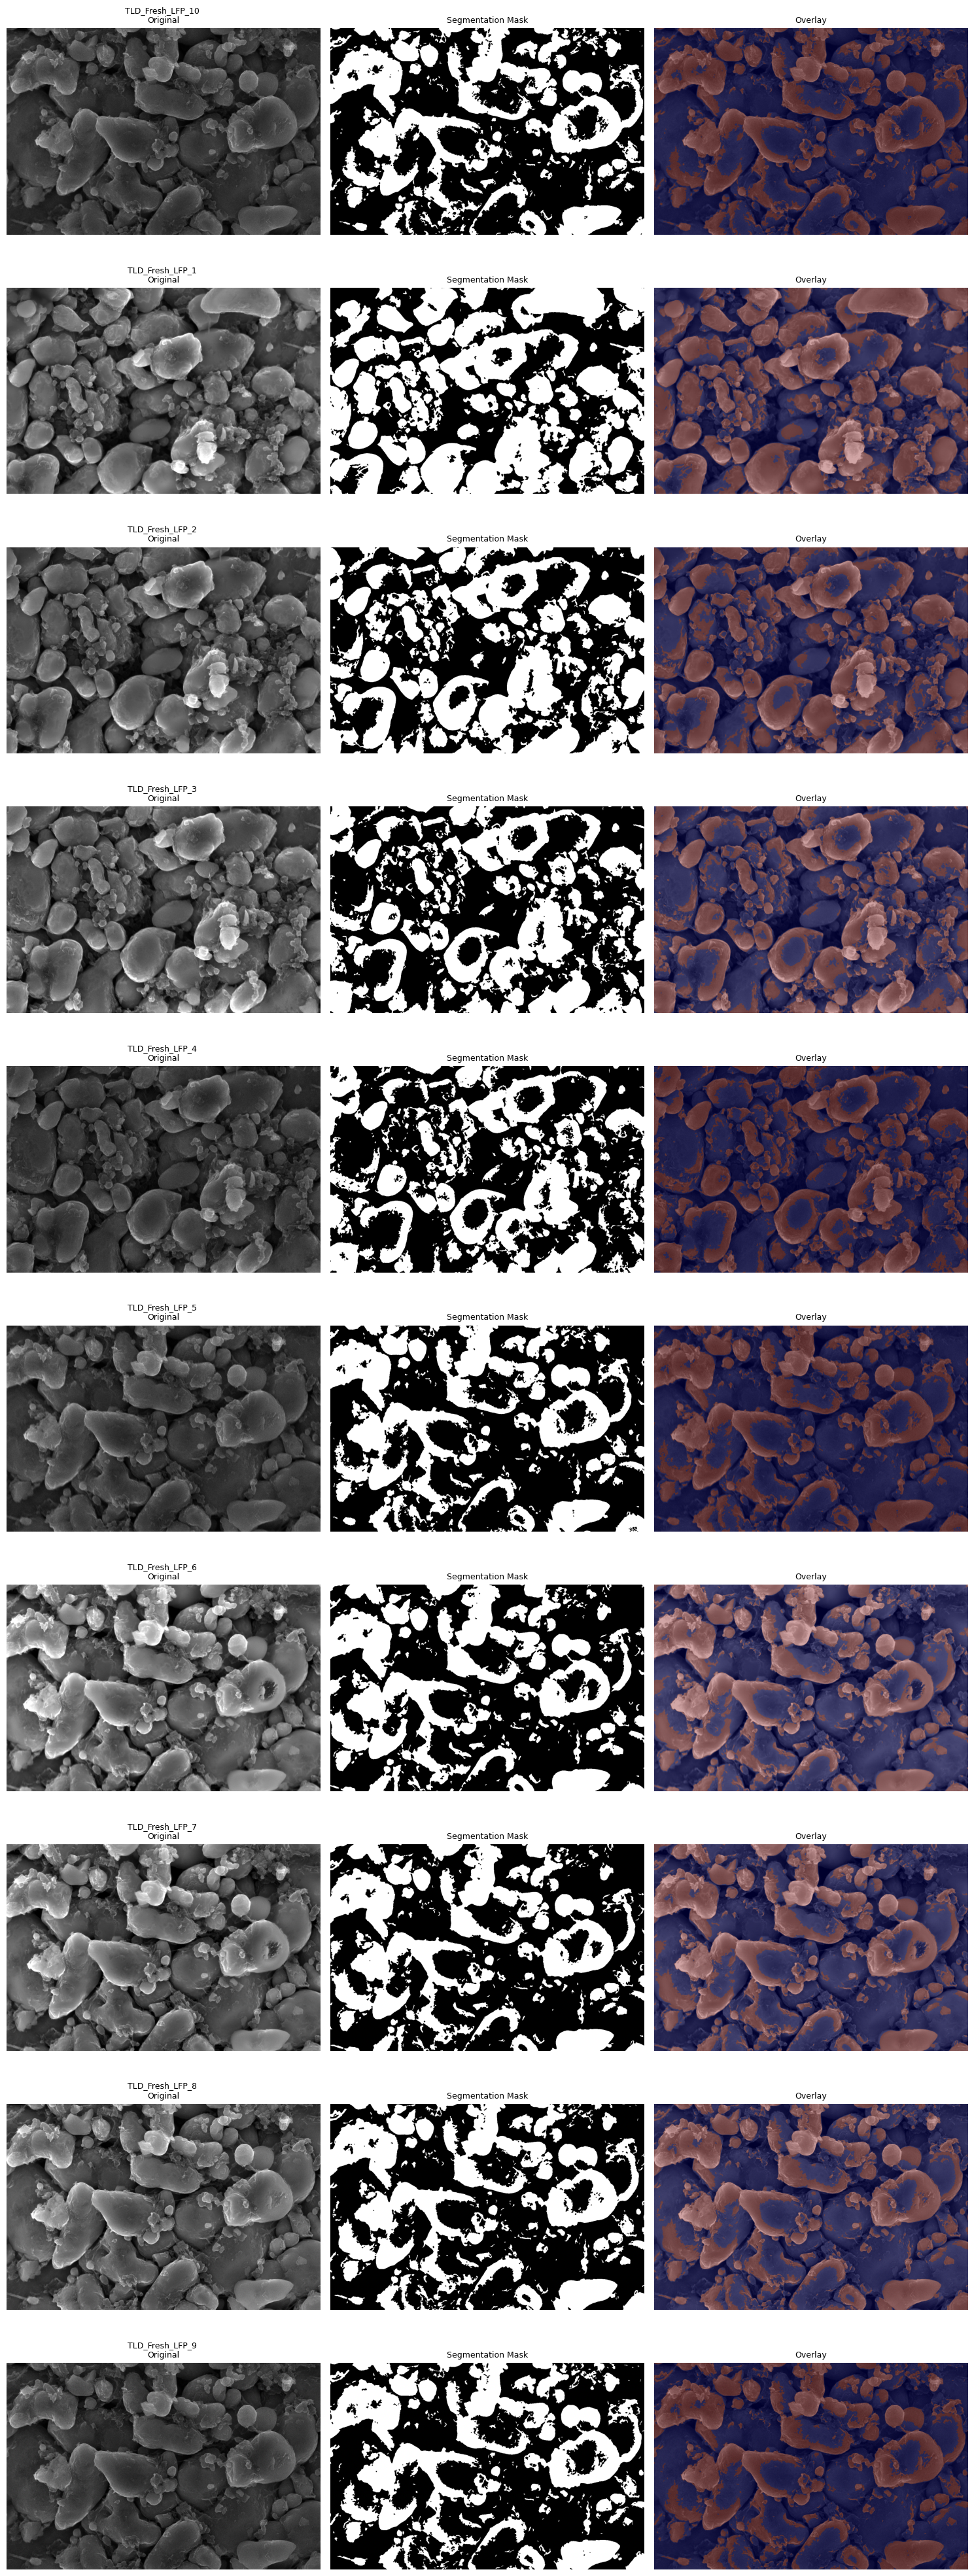

In [45]:
from pathlib import Path
import tifffile
import matplotlib.pyplot as plt


BASE_DIR = Path.cwd().parents[1]

MASK_DIR = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "images"
    / "segmented_masks"
    / "Param_1"
)

IMAGE_DIR = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "images"
    / "cropped"
    / "Param_1"
)


mask_files = sorted(
    MASK_DIR.glob("*_mask.tif")
)


n_images = len(mask_files)


# Three columns:
# Original | Mask | Overlay
cols = 3
rows = n_images


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, 4 * rows)
)


# Handle single image case
if n_images == 1:
    axes = axes.reshape(1, -1)


for i, mask_path in enumerate(mask_files):

    # Load mask
    mask = tifffile.imread(
        mask_path
    )


    # Find original image
    image_path = (
        IMAGE_DIR
        / mask_path.name.replace(
            "_mask",
            ""
        )
    )


    image = tifffile.imread(
        image_path
    )


    # -----------------------
    # Original image
    # -----------------------
    axes[i, 0].imshow(
        image,
        cmap="gray"
    )

    axes[i, 0].set_title(
        f"{mask_path.stem.replace('_mask','')} \nOriginal",
        fontsize=9
    )

    axes[i, 0].axis("off")


    # -----------------------
    # Segmentation mask
    # -----------------------
    axes[i, 1].imshow(
        mask,
        cmap="gray"
    )

    axes[i, 1].set_title(
        "Segmentation Mask",
        fontsize=9
    )

    axes[i, 1].axis("off")


    # -----------------------
    # Overlay
    # -----------------------
    axes[i, 2].imshow(
        image,
        cmap="gray"
    )

    axes[i, 2].imshow(
        mask,
        cmap="jet",
        alpha=0.35
    )

    axes[i, 2].set_title(
        "Overlay",
        fontsize=9
    )

    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

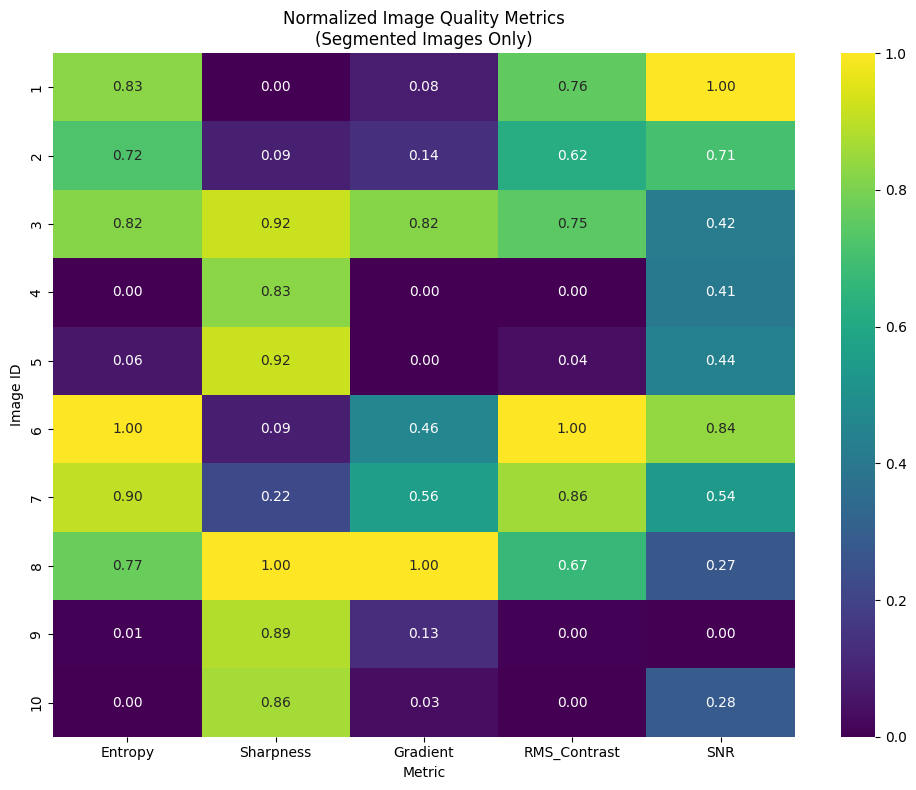

In [52]:
# Load segmentation results
SEG_FILE = BASE_DIR / "FIB_SEM_optimization" / "results" / "Param_1" / "segmentation_quality_param_1.csv"

metrics = [
        "Entropy",
        "Sharpness",
        "Gradient",
        "RMS_Contrast",
        "SNR"
    ]

seg_results = pd.read_csv(
    SEG_FILE
)


# Keep only segmented images
quality_results_filtered = quality_results.merge(
    seg_results[["image_id"]],
    on="image_id",
    how="inner"
)


# Create normalized metric table
quality_norm = quality_results_filtered.set_index(
    "image_id"
)[metrics]


# Normalize each metric between 0 and 1
quality_norm = (
    quality_norm - quality_norm.min()
) / (
    quality_norm.max() - quality_norm.min()
)


plt.figure(figsize=(10, 8))

sns.heatmap(
    quality_norm,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)


plt.title(
    "Normalized Image Quality Metrics\n(Segmented Images Only)"
)

plt.xlabel("Metric")
plt.ylabel("Image ID")


plt.tight_layout()
plt.show()

In [53]:
from sklearn.preprocessing import MinMaxScaler


score_metrics = [
    "separability",
    "segmented_fraction",
    "connected_components",
    "mean_region_area"
]


scaler = MinMaxScaler()


seg_results[
    score_metrics
] = scaler.fit_transform(
    seg_results[score_metrics]
)


seg_results["segmentation_score"] = (
    0.4 * seg_results["separability"]
    +
    0.2 * seg_results["connected_components"]
    +
    0.2 * seg_results["mean_region_area"]
    -
    0.2 * seg_results["threshold_instability"]
)


seg_results.sort_values(
    "segmentation_score",
    ascending=False
)

,threshold,segmented_fraction,connected_components,mean_region_area,median_region_area,separability,threshold_instability,detector,sample_state,material,image_id,segmentation_score
6,0.455078,0.053444,0.440860,0.216723,127.0,1.000000,0.118865,TLD,Fresh,LFP,6,0.507743
0,0.355821,1.000000,0.000000,1.000000,127.0,0.816644,0.113884,TLD,Fresh,LFP,1,0.503881
7,0.408203,0.000312,0.645161,0.106394,109.0,0.908407,0.115399,TLD,Fresh,LFP,7,0.490594
9,0.259648,0.000000,0.956989,0.000000,69.0,0.710508,0.123726,TLD,Fresh,LFP,9,0.450856
8,0.381725,0.059052,0.924731,0.028269,92.5,0.706868,0.125347,TLD,Fresh,LFP,8,0.448278
1,0.263647,0.000818,0.817204,0.044213,95.5,0.708744,0.125633,TLD,Fresh,LFP,10,0.430655
5,0.264464,0.002758,0.483871,0.176150,123.0,0.655150,0.124880,TLD,Fresh,LFP,5,0.369088
4,0.253322,0.096056,1.000000,0.016812,88.0,0.109745,0.137198,TLD,Fresh,LFP,4,0.219821
2,0.340029,0.529967,0.408602,0.425981,239.0,0.102573,0.133942,TLD,Fresh,LFP,2,0.181157
3,0.381676,0.240151,0.827957,0.119288,134.0,0.000000,0.138057,TLD,Fresh,LFP,3,0.161838


In [54]:
from sklearn.preprocessing import MinMaxScaler


quality_metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


# Make a copy to avoid modifying original data
quality_scored = quality_results.copy()


# Normalize metrics 0-1
scaler = MinMaxScaler()

quality_scored[
    quality_metrics
] = scaler.fit_transform(
    quality_scored[quality_metrics]
)


# Calculate image quality score
quality_scored["image_quality_score"] = (
    0.05 * quality_scored["Entropy"]
    +
    0.20 * quality_scored["Sharpness"]
    +
    0.25 * quality_scored["Gradient"]
    +
    0.20 * quality_scored["RMS_Contrast"]
    +
    0.30 * quality_scored["SNR"]
)


# Rank images
quality_scored = quality_scored.sort_values(
    "image_quality_score",
    ascending=False
)


quality_scored[
    [
        "image_id",
        "image_quality_score",
        "SNR",
        "Gradient",
        "Sharpness",
        "RMS_Contrast",
        "Entropy"
    ]
]

,image_id,image_quality_score,SNR,Gradient,Sharpness,RMS_Contrast,Entropy
68,67,0.649643,0.142814,0.932560,0.685650,1.000000,0.730587
74,73,0.605234,0.068303,0.967450,0.881678,0.670197,0.650116
76,75,0.590659,0.159523,0.959166,0.598392,0.732644,0.736063
75,74,0.583649,0.169284,0.900417,0.572929,0.777690,0.752708
35,35,0.576930,0.960410,0.282096,0.059119,0.793788,0.954027
...,...,...,...,...,...,...,...
57,56,0.060683,0.030458,0.011395,0.000167,0.001595,0.966886
56,55,0.058722,0.028452,0.010169,0.000160,0.001579,0.945920
43,43,0.056640,0.035500,0.009901,0.000097,0.000950,0.866099
47,46,0.055133,0.015897,0.018289,0.000263,0.000968,0.910905


In [56]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# -------------------------------
# Load results
# -------------------------------

quality_results = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results.csv"
)
quality_results_normalised = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "image_quality_results_normalised.csv"
)

seg_results = pd.read_csv(
    BASE_DIR / "FIB_SEM_optimization" / "results" / "Param_1" / "segmentation_quality_param_1.csv"
)


# -------------------------------
# Image Quality Score
# -------------------------------

quality_metrics = [
    "Entropy",
    "Sharpness",
    "Gradient",
    "RMS_Contrast",
    "SNR"
]


quality_scored_1 = quality_results.copy()

scaler = MinMaxScaler()

quality_scored_1[
    quality_metrics
] = scaler.fit_transform(
    quality_scored_1[quality_metrics]
)


quality_scored_1["image_quality_score"] = (
    0.05 * quality_scored_1["Entropy"]
    +
    0.20 * quality_scored_1["Sharpness"]
    +
    0.25 * quality_scored_1["Gradient"]
    +
    0.20 * quality_scored_1["RMS_Contrast"]
    +
    0.30 * quality_scored_1["SNR"]
)


# -------------------------------
# Segmentation Score
# -------------------------------

seg_metrics = [
    "separability",
    "connected_components",
    "mean_region_area"
]


seg_scored = seg_results.copy()


seg_scored[
    seg_metrics
] = scaler.fit_transform(
    seg_scored[seg_metrics]
)


seg_scored["segmentation_score"] = (
    0.40 * seg_scored["separability"]
    +
    0.20 * seg_scored["connected_components"]
    +
    0.20 * seg_scored["mean_region_area"]
    -
    0.20 * seg_scored["threshold_instability"]
)


# -------------------------------
# Combine Scores
# -------------------------------

combined_results = quality_scored.merge(
    seg_scored[
        [
            "detector",
            "sample_state",
            "material",
            "image_id",
            "segmentation_score"
        ]
    ],
    on=[
        "detector",
        "sample_state",
        "material",
        "image_id"
    ],
    how="inner"
)


# Final FIB-SEM optimisation score
combined_results["final_score"] = (
    0.4 * combined_results["image_quality_score"]
    +
    0.6 * combined_results["segmentation_score"]
)


# Rank best images
combined_results = combined_results.sort_values(
    "final_score",
    ascending=False
)


# Display ranking
combined_results[
    [
        "detector",
        "sample_state",
        "material",
        "image_id",
        "image_quality_score",
        "segmentation_score",
        "final_score"
    ]
]

,detector,sample_state,material,image_id,image_quality_score,segmentation_score,final_score
2,TLD,Fresh,LFP,6,0.403366,0.507743,0.465992
0,TLD,Fresh,LFP,8,0.476854,0.448278,0.459708
3,TLD,Fresh,LFP,7,0.395044,0.490594,0.452374
4,TLD,Fresh,LFP,1,0.353681,0.503881,0.443801
9,TLD,Fresh,LFP,9,0.318330,0.450856,0.397846
8,TLD,Fresh,LFP,10,0.323738,0.430655,0.387888
5,TLD,Fresh,LFP,5,0.340881,0.369088,0.357805
1,TLD,Fresh,LFP,3,0.472120,0.161838,0.285950
7,TLD,Fresh,LFP,4,0.324356,0.219821,0.261635
6,TLD,Fresh,LFP,2,0.338158,0.181157,0.243958
